## Time zones

This example demonstrates how to set time zones for the purposes of automatic metadata formatting in titles and labels. Note that earthkit-plots will attempt to identify established time zone conventions in metadata, but if these are not found, **it will assume UTC**. In the example below, we demonstrate how to use the `%Z` format spec and the magic `utc_offset` key to include the ime zone code and the offset from UTC in a title, while setting the time zone to Asia/Tokyo. Notice the warnings that there is no time zone available in the metadata, and that is is (in this case correctly) assuming UTC.

era5-hourly-2t-20230724T1200Z.nc:   0%|          | 0.00/1.99M [00:00<?, ?B/s]

Attempting time zone conversion, but some data has no time zone metadata; assuming UTC
Attempting time zone conversion, but some data has no time zone metadata; assuming UTC
Attempting time zone conversion, but some data has no time zone metadata; assuming UTC


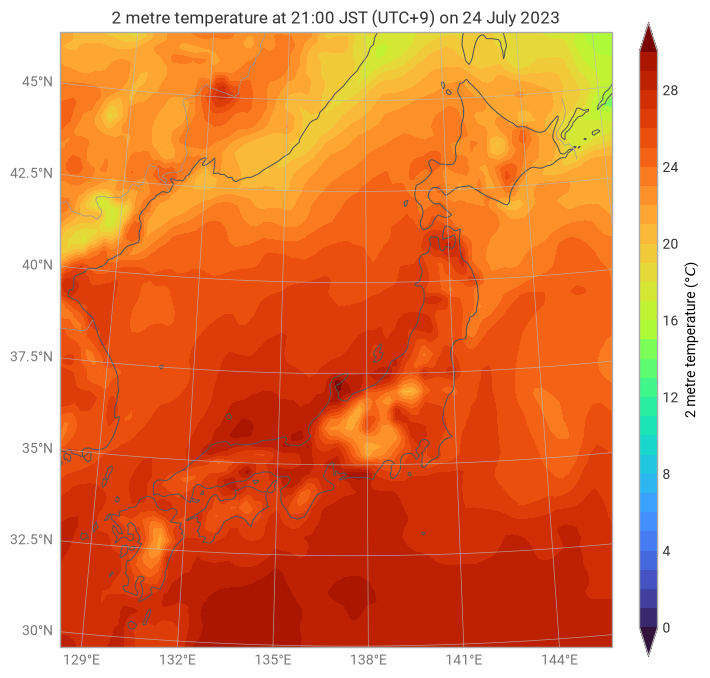

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

data = ekd.from_source("sample", "era5-hourly-2t-20230724T1200Z.nc")

chart = ekp.Map(domain="Japan")

chart.plot(data, levels=range(31), colors="turbo", units="celsius")

with ekp.schema.set(time_zone="Asia/Tokyo"):
    chart.title("{variable_name} at {time:%H:%M %Z} ({utc_offset}) on {time:%-d %B %Y}")

chart.coastlines()
chart.borders()
chart.gridlines()

chart.legend(location="right")

chart.show()